# Miniproyecto VA: ocupación de plazas de aparcamiento (PKLot)
Detección de plazas **libres/ocupadas** en imágenes de tres aparcamientos con vistas distintas (UFPR04, UFPR05, PUCPR) y detección de **coches** que las ocupan.

Pipeline: homografía/rectificación por plaza (BT2) → clásico: Otsu propio + morfología + HOG (BT3/BT4) → RANSAC/Hough (BT7) → YOLO (BT5) → DINOv2 y SAM (BT6) → comparativa, overlay AR y demo interactiva (BT1/BT2f).

Ejecución: `pip install -r requirements.txt`, descargar PKLot en `data/` (ver `INSTALL.txt`) y ejecutar las celdas en orden.

## 0. Setup, semillas y configuración (BT1a)

In [20]:
import os, sys, glob, json, time, random, shutil, tarfile, warnings
from pathlib import Path
import xml.etree.ElementTree as ET
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
import torch; torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CFG = dict(
    n_img={"UFPR04": 500, "UFPR05": 500, "PUCPR": 250},  # imagenes por camara (RTX 2070S)
    patch=64,                 # lado del parche rectificado
    max_patches_dino=20000,   # limite de parches DINOv2 (GPU)
    n_yolo_eval=120,          # imagenes de test para YOLO
    n_sam_imgs=18,            # imagenes para SAM
    finetune=True, ft_epochs=20, ft_imgsz=960, ft_n_train=300, ft_batch=8,
)
def imread(p):
    """cv2.imread falla con rutas no ASCII en Windows."""
    return cv2.imdecode(np.fromfile(str(p), np.uint8), cv2.IMREAD_COLOR)

ROOT = Path.cwd()
DATA = ROOT / "data"
OUT = ROOT / "outputs"; OUT.mkdir(exist_ok=True)
print("device:", DEVICE, "| cwd:", ROOT)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0), "| VRAM:", round(torch.cuda.get_device_properties(0).total_memory/1e9, 1), "GB")
else:
    print("AVISO: ejecutando en CPU. Instala PyTorch con CUDA para aprovechar la GPU.")


device: cuda | cwd: c:\Users\Roland\Desktop\Universidad Master IA\VA - Visión artifical\ProyectoParking
GPU: NVIDIA GeForce RTX 2070 SUPER | VRAM: 8.6 GB


## 1. Datos: PKLot, manifiesto y splits sin fuga temporal
PKLot trae por imagen un XML con el polígono de cada plaza y su estado. Se muestrean imágenes por cámara y se asigna **cada día completo a un solo split** (cronológico 60/20/20) para que fotogramas casi idénticos no caigan en splits distintos. PUCPR se usa como prueba **externa** (otra vista/ángulo).

In [21]:
def find_pklot_root():
    for c in [DATA/"PKLot"/"PKLot", DATA/"PKLot", DATA]:
        if (c/"PUCPR").exists(): return c
    tgz = DATA/"PKLot.tar.gz"
    if tgz.exists():
        print("Extrayendo", tgz, "...")
        with tarfile.open(tgz) as tf:
            members = [m for m in tf if "PKLotSegmented" not in m.name]
            tf.extractall(DATA, members=members)
        return find_pklot_root()
    raise FileNotFoundError("Descarga PKLot.tar.gz en data/ (ver INSTALL.txt)")
PK = find_pklot_root(); print("PKLot en", PK)

def parse_xml(xml_path):
    root = ET.parse(xml_path).getroot()
    out = []
    for sp_ in root.iter("space"):
        occ = sp_.get("occupied")
        pts = [(int(p.get("x")), int(p.get("y"))) for p in sp_.iter("point")]
        if occ is None or len(pts) < 4: continue
        out.append((int(sp_.get("id")), int(occ), pts[:4]))
    return out

def order_corners(pts):
    pts = np.array(pts, np.float32)
    c = pts.mean(0); ang = np.arctan2(pts[:,1]-c[1], pts[:,0]-c[0])
    pts = pts[np.argsort(ang)]            # sentido horario en coords imagen
    k = np.argmin(pts.sum(1))             # esquina sup-izq = min(x+y)
    return np.roll(pts, -k, axis=0)       # TL, TR, BR, BL

def build_manifest():
    rows = []
    for jpg in PK.rglob("*.jpg"):
        p = jpg.relative_to(PK).parts
        if len(p) < 4: continue
        rows.append(dict(path=str(jpg), cam=p[-4], weather=p[-3], day=p[-2], name=jpg.stem))
    df = pd.DataFrame(rows)
    df = df[df.cam.isin(CFG["n_img"])].copy()
    df["split"] = ""
    for cam_ in ["UFPR04", "UFPR05"]:
        days = sorted(df[df.cam == cam_].day.unique())
        n = len(days); a, b = int(.6*n), int(.8*n)
        m = {d: ("train" if i < a else "val" if i < b else "test") for i, d in enumerate(days)}
        df.loc[df.cam == cam_, "split"] = df[df.cam == cam_].day.map(m)
    df.loc[df.cam == "PUCPR", "split"] = "test_external"
    parts = []
    for cam_, g in df.groupby("cam"):
        frac = min(1.0, CFG["n_img"][cam_] / len(g))
        parts.append(g.groupby(["split", "weather"], group_keys=False).sample(frac=frac, random_state=SEED))
    return pd.concat(parts).sort_values(["cam", "day", "name"]).reset_index(drop=True)

MAN_PATH = OUT/"manifest.csv"
if MAN_PATH.exists(): man = pd.read_csv(MAN_PATH)
else: man = build_manifest(); man.to_csv(MAN_PATH, index=False)
print(man.groupby(["cam", "split"]).size().unstack(fill_value=0))
print(man.groupby(["cam", "weather"]).size().unstack(fill_value=0))

PKLot en c:\Users\Roland\Desktop\Universidad Master IA\VA - Visión artifical\ProyectoParking\data\PKLot\PKLot
split   test  test_external  train  val
cam                                    
PUCPR      0            151      0    0
UFPR04    69              0    175   57
UFPR05    64              0    178   58
weather  Cloudy  Rainy  Sunny
cam                          
PUCPR        45     28     78
UFPR04      112     23    166
UFPR05      103     16    181


33797 plazas | 0.511 ocupadas
                       size   mean
cam    split                      
PUCPR  test_external  14111  0.448
UFPR04 test            1929  0.477
       train           4884  0.487
       val              890  0.253
UFPR05 test            2553  0.640
       train           7113  0.528
       val             2317  0.879


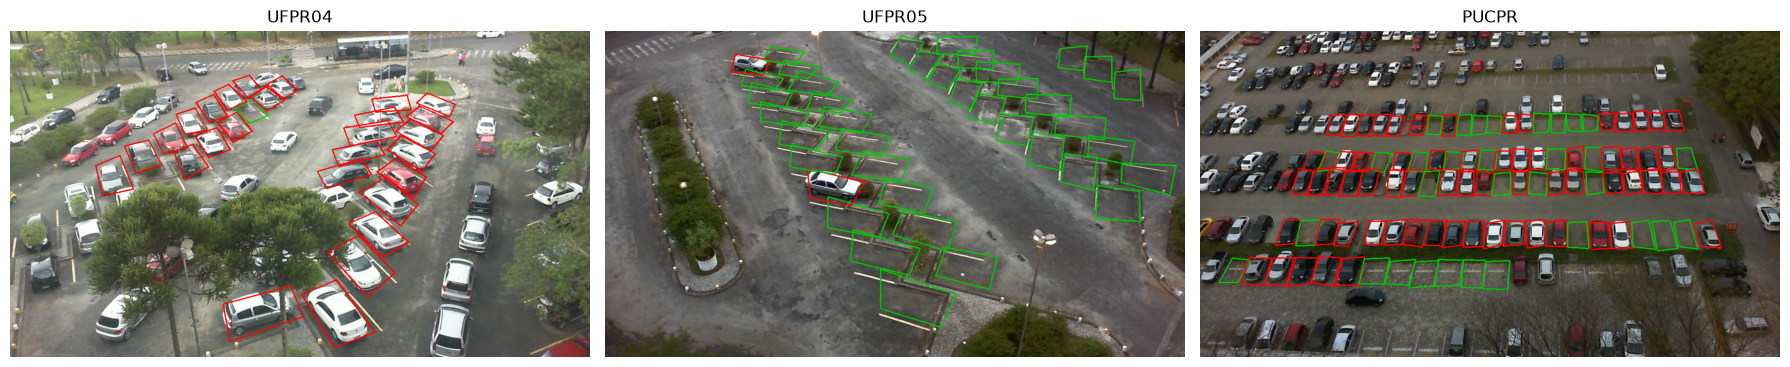

In [22]:
SP_PATH = OUT/"spaces.pkl"
if SP_PATH.exists():
    sp = pd.read_pickle(SP_PATH)
else:
    recs = []
    for r in tqdm(man.itertuples(), total=len(man)):
        for sid, occ, pts in parse_xml(Path(r.path).with_suffix(".xml")):
            recs.append(dict(path=r.path, cam=r.cam, split=r.split, weather=r.weather, day=r.day,
                             sid=sid, occ=occ, corners=order_corners(pts)))
    sp = pd.DataFrame(recs); sp.to_pickle(SP_PATH)
print(len(sp), "plazas |", sp.occ.mean().round(3), "ocupadas")
print(sp.groupby(["cam", "split"]).occ.agg(["size", "mean"]).round(3))

def draw_spaces(img, spaces, thick=2):
    out = img.copy()
    for c, o in spaces:
        cv2.polylines(out, [c.astype(np.int32)], True, (0,0,255) if o else (0,200,0), thick)
    return out
fig, axs = plt.subplots(1, 3, figsize=(18, 4))
for ax, cam_ in zip(axs, ["UFPR04", "UFPR05", "PUCPR"]):
    p = man[man.cam == cam_].path.iloc[0]; s = sp[sp.path == p]
    ax.imshow(cv2.cvtColor(draw_spaces(imread(p), zip(s.corners, s.occ)), cv2.COLOR_BGR2RGB)); ax.set_title(cam_); ax.axis("off")
plt.tight_layout(); plt.show()

## 2. Homografía y rectificación de cada plaza (BT2a, BT2b)
**DLT con normalización de Hartley implementado a mano**, comparado con `cv2.findHomography`. Cada plaza (cuadrilátero en perspectiva) se rectifica a un parche frontal de 64×64, que luego se usa como entrada de los clasificadores.

In [23]:
def normalize_pts(P):
    c = P.mean(0); d = np.sqrt(((P-c)**2).sum(1)).mean()
    s = np.sqrt(2)/d
    T = np.array([[s,0,-s*c[0]],[0,s,-s*c[1]],[0,0,1]])
    Ph = np.c_[P, np.ones(len(P))] @ T.T
    return Ph[:, :2], T

def dlt_homography(src, dst):
    """H tal que dst ~ H src (DLT normalizado, SVD)."""
    src = np.asarray(src, float); dst = np.asarray(dst, float)
    s, Ts = normalize_pts(src); d, Td = normalize_pts(dst)
    A = []
    for (x, y), (u, v) in zip(s, d):
        A.append([-x, -y, -1, 0, 0, 0, u*x, u*y, u])
        A.append([0, 0, 0, -x, -y, -1, v*x, v*y, v])
    _, _, Vt = np.linalg.svd(np.array(A))
    H = np.linalg.inv(Td) @ Vt[-1].reshape(3, 3) @ Ts
    return H / H[2, 2]

def apply_H(H, P):
    Ph = np.c_[P, np.ones(len(P))] @ H.T
    return Ph[:, :2] / Ph[:, 2:3]

PS = CFG["patch"]
DST = np.array([[0,0],[PS-1,0],[PS-1,PS-1],[0,PS-1]], np.float32)

def rectify(img, corners, size=PS):
    H = dlt_homography(corners, DST)
    return cv2.warpPerspective(img, H, (size, size), flags=cv2.INTER_AREA)

errs = []
for c in sp.corners.sample(300, random_state=SEED):
    H1 = dlt_homography(c, DST); H2, _ = cv2.findHomography(c, DST)
    errs.append((np.linalg.norm(apply_H(H1, c)-DST, axis=1).max(), np.linalg.norm(apply_H(H1, c)-apply_H(H2, c), axis=1).max()))
errs = np.array(errs); print(f"error reproyeccion DLT propia: max={errs[:,0].max():.2e} px | diferencia vs cv2: max={errs[:,1].max():.2e} px")

error reproyeccion DLT propia: max=7.98e-13 px | diferencia vs cv2: max=7.97e-13 px


train/val/test/ext: 11997 3207 4482 14111


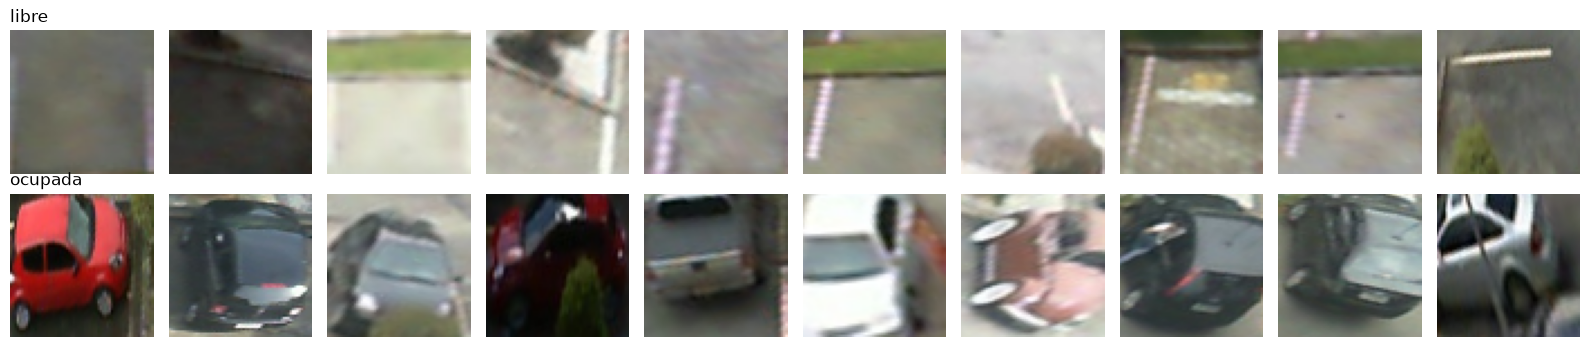

In [24]:
PATCH_PATH = OUT/"patches.npz"
if PATCH_PATH.exists():
    X = np.load(PATCH_PATH)["X"]; assert len(X) == len(sp)
else:
    X = np.zeros((len(sp), PS, PS, 3), np.uint8)
    idx_by_path = sp.groupby("path").indices
    for path_, idx in tqdm(idx_by_path.items(), total=len(idx_by_path)):
        img_ = imread(path_)
        for i in idx: X[i] = rectify(img_, sp.corners.iloc[i])
    np.savez_compressed(PATCH_PATH, X=X)
y = sp.occ.values; split = sp.split.values; cam = sp.cam.values
tr, va, te, ext = [split == s_ for s_ in ["train", "val", "test", "test_external"]]
print("train/val/test/ext:", tr.sum(), va.sum(), te.sum(), ext.sum())
fig, axs = plt.subplots(2, 10, figsize=(16, 3.5))
rng = np.random.default_rng(SEED)
for r_, lab in enumerate([0, 1]):
    for a, i in zip(axs[r_], rng.choice(np.where(y == lab)[0], 10, replace=False)):
        a.imshow(cv2.cvtColor(X[i], cv2.COLOR_BGR2RGB)); a.axis("off")
    axs[r_][0].set_title("libre" if lab == 0 else "ocupada", loc="left")
plt.tight_layout(); plt.show()

## 3. Métricas comunes y baseline clásico: Otsu propio + morfología (BT3c, BT3d, BT3g)
Otsu implementado a mano (histograma + máxima varianza interclase), validado contra OpenCV. Sobre el parche rectificado se calculan descriptores simples (fracción de primer plano Otsu, densidad de bordes Canny, componentes conexas tras apertura/cierre, saturación…) y se clasifica con un modelo ligero.

In [25]:
RESULTS = {}
def evaluate(name, yt, yp):
    p, r, f, _ = precision_recall_fscore_support(yt, yp, average="binary", zero_division=0)
    RESULTS[name] = dict(acc=accuracy_score(yt, yp), prec=p, rec=r, f1=f)
    return RESULTS[name]

def eval_all(name, pred, mask=None):
    for tag, m in [("val", va), ("test", te), ("ext", ext)]:
        m = m if mask is None else (m & mask)
        if m.sum(): evaluate(f"{name} [{tag}]", y[m], pred[m])
    return pd.DataFrame({k: v for k, v in RESULTS.items() if k.startswith(name)}).T.round(3)

def otsu_threshold(gray):
    """Otsu propio: maximiza la varianza interclase del histograma de 256 niveles."""
    hist = np.bincount(gray.ravel(), minlength=256).astype(float); p = hist/hist.sum()
    w0 = np.cumsum(p); mu = np.cumsum(p*np.arange(256)); mt = mu[-1]
    with np.errstate(divide="ignore", invalid="ignore"):
        sb = (mt*w0 - mu)**2/(w0*(1-w0))
    return int(np.nanargmax(sb))

def cv_otsu(g): return int(cv2.threshold(g, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)[0])
ds = []
for i in range(0, len(X), max(1, len(X)//500)):
    g_ = cv2.cvtColor(X[i], cv2.COLOR_BGR2GRAY); ds.append(abs(otsu_threshold(g_) - cv_otsu(g_)))
print("diferencia media |t_propio - t_cv2| (niveles de gris) =", round(float(np.mean(ds)), 3), "| max =", max(ds))

diferencia media |t_propio - t_cv2| (niveles de gris) = 0.0 | max = 0


In [26]:
K3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
def classic_features(patch):
    g = cv2.GaussianBlur(cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY), (3, 3), 0)
    t = otsu_threshold(g); m = (g > t).astype(np.uint8)
    if m.mean() > .5: m = 1 - m                      # primer plano = clase minoritaria
    m = cv2.morphologyEx(cv2.morphologyEx(m, cv2.MORPH_OPEN, K3), cv2.MORPH_CLOSE, K3)
    n, lab, st, _ = cv2.connectedComponentsWithStats(m)
    areas = st[1:, cv2.CC_STAT_AREA] if n > 1 else np.array([0])
    edges = cv2.Canny(g, 60, 150)
    hsv = cv2.cvtColor(patch, cv2.COLOR_BGR2HSV)
    return [t, m.mean(), edges.mean()/255, g.std(), n-1, areas.max()/g.size, hsv[...,1].mean(), hsv[...,1].std(), np.abs(np.diff(g.astype(float), axis=1)).mean()]

F_cls = np.array([classic_features(p) for p in tqdm(X)])
from sklearn.ensemble import HistGradientBoostingClassifier
clf_cls = HistGradientBoostingClassifier(random_state=SEED).fit(F_cls[tr], y[tr])
pred_cls = clf_cls.predict(F_cls)
eval_all("Otsu+morfologia", pred_cls)

  0%|          | 0/33797 [00:00<?, ?it/s]

,acc,prec,rec,f1
Otsu+morfologia [val],0.977,0.990,0.978,0.984
Otsu+morfologia [test],0.960,0.964,0.965,0.965
Otsu+morfologia [ext],0.949,0.944,0.943,0.943


## 4. HOG + SVM lineal (BT4c)

In [27]:
from skimage.feature import hog
from sklearn.svm import LinearSVC
def hog_feat(p): return hog(cv2.cvtColor(p, cv2.COLOR_BGR2GRAY), orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2), block_norm="L2-Hys")
F_hog = np.array([hog_feat(p) for p in tqdm(X)])
svm = LinearSVC(C=0.1, random_state=SEED, max_iter=5000).fit(F_hog[tr], y[tr])
pred_hog = svm.predict(F_hog)
eval_all("HOG+SVM", pred_hog)

  0%|          | 0/33797 [00:00<?, ?it/s]

,acc,prec,rec,f1
HOG+SVM [val],0.953,0.966,0.968,0.967
HOG+SVM [test],0.943,0.955,0.945,0.950
HOG+SVM [ext],0.926,0.902,0.937,0.919


## 5. Geometría robusta: RANSAC propio y transformada de Hough (BT7a, BT7b)
Las filas de plazas son colineales: ajustamos la recta de cada fila a los centros de las plazas con un **RANSAC implementado a mano** (multi-instancia: se retiran los inliers y se repite), comparándolo con mínimos cuadrados cuando hay *outliers*. Además se extraen las direcciones dominantes con **Hough** sobre bordes Canny.

4 filas detectadas con RANSAC multi-instancia
   outliers  err_LS_deg  err_RANSAC_deg
0       0.0       0.000           0.036
1       0.1       1.101           0.036
2       0.2      10.592           0.036
3       0.3       7.769           0.036
4       0.4       9.656           0.036


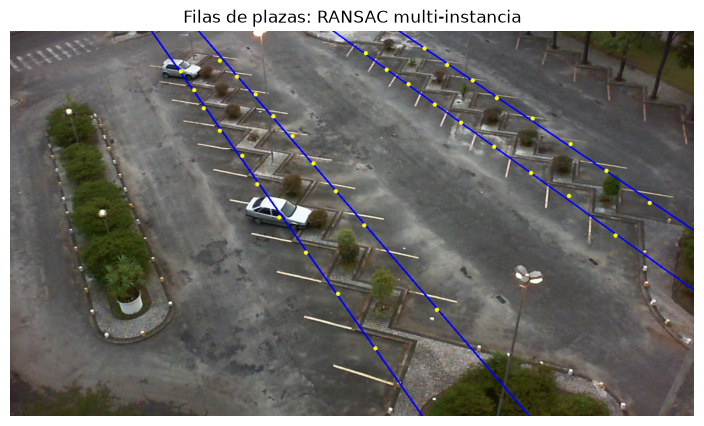

In [28]:
def fit_line_ls(P):
    c = P.mean(0); _, _, Vt = np.linalg.svd(P-c); return c, Vt[0]
def point_line_dist(P, c, d): n = np.array([-d[1], d[0]]); return np.abs((P-c) @ n)
def ransac_line(P, thr=3.0, iters=500, rng=None):
    rng = rng or np.random.default_rng(SEED); best, best_in = None, None
    for _ in range(iters):
        i, j = rng.choice(len(P), 2, replace=False)
        d = P[j]-P[i]; nd = np.linalg.norm(d)
        if nd < 1e-6: continue
        d = d/nd; inl = point_line_dist(P, P[i], d) < thr
        if best_in is None or inl.sum() > best_in.sum(): best, best_in = (P[i], d), inl
    c, d = fit_line_ls(P[best_in]); return c, d, best_in

path0 = man[man.cam == "UFPR05"].path.iloc[0]; s = sp[sp.path == path0]
C_ = np.array([c.mean(0) for c in s.corners])
rest, lines = C_.copy(), []
while len(rest) >= 6 and len(lines) < 6:
    c0, d0, inl = ransac_line(rest, thr=6)
    if inl.sum() < 5: break
    lines.append((c0, d0, rest[inl])); rest = rest[~inl]
img0 = imread(path0); vis = img0.copy()
for c0, d0, pts in lines:
    cv2.line(vis, tuple((c0-1500*d0).astype(int)), tuple((c0+1500*d0).astype(int)), (255,0,0), 2)
    for q in pts: cv2.circle(vis, tuple(q.astype(int)), 4, (0,255,255), -1)
print(len(lines), "filas detectadas con RANSAC multi-instancia")

c0, d0, pts = max(lines, key=lambda l: len(l[2]))
true_ang = np.degrees(np.arctan2(d0[1], d0[0]))
def ang_err(d): a = np.degrees(np.arctan2(d[1], d[0])); return abs(((a-true_ang)+90) % 180 - 90)
rng = np.random.default_rng(SEED); res = []
for frac in [0, .1, .2, .3, .4]:
    P = pts.copy(); n_out = int(frac*len(P))
    out = rng.uniform([P[:,0].min(), P[:,1].min()-150], [P[:,0].max(), P[:,1].max()+150], (n_out, 2))
    Pn = np.r_[P, out]
    res.append((frac, ang_err(fit_line_ls(Pn)[1]), ang_err(ransac_line(Pn, thr=4)[1])))
print(pd.DataFrame(res, columns=["outliers", "err_LS_deg", "err_RANSAC_deg"]).round(3))
plt.figure(figsize=(12, 5)); plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.title("Filas de plazas: RANSAC multi-instancia"); plt.show()

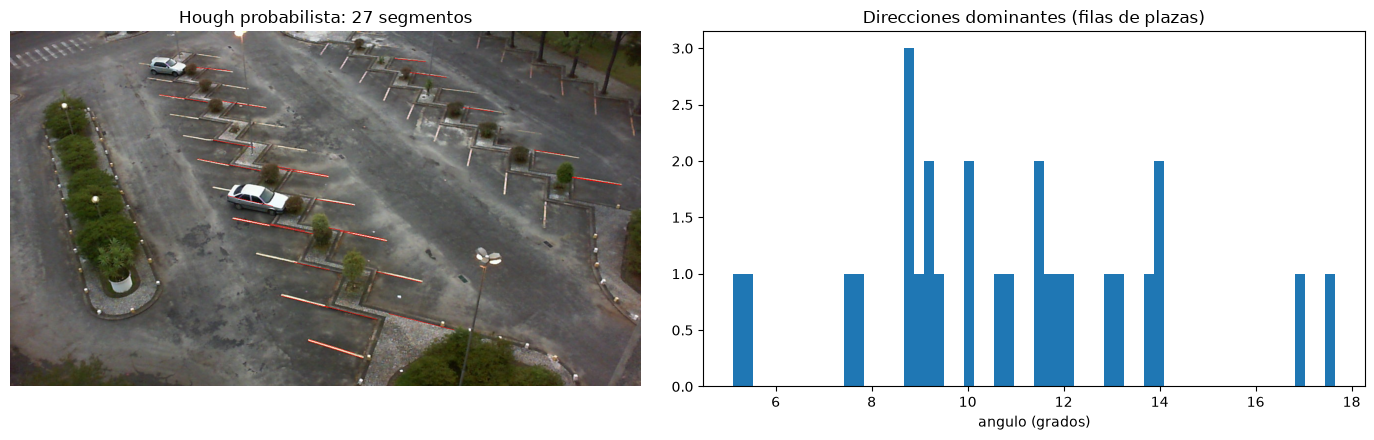

In [29]:
g_ = cv2.GaussianBlur(cv2.cvtColor(img0, cv2.COLOR_BGR2GRAY), (5, 5), 0)
edges = cv2.Canny(g_, 80, 200)
segs = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=80, minLineLength=60, maxLineGap=8).reshape(-1, 4)
vis2 = img0.copy(); angs = []
for x1, y1, x2, y2 in segs:
    cv2.line(vis2, (x1, y1), (x2, y2), (0, 0, 255), 1); angs.append(np.degrees(np.arctan2(y2-y1, x2-x1)) % 180)
fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
axs[0].imshow(cv2.cvtColor(vis2, cv2.COLOR_BGR2RGB)); axs[0].axis("off"); axs[0].set_title(f"Hough probabilista: {len(segs)} segmentos")
axs[1].hist(angs, bins=60); axs[1].set_xlabel("angulo (grados)"); axs[1].set_title("Direcciones dominantes (filas de plazas)")
plt.tight_layout(); plt.show()

## 6. YOLO: detección de coches y ocupación (BT5b, BT5d, BT5g, BT5h)
1. **YOLOv8 preentrenado en COCO** (coche/moto/bus/camión) → una plaza se marca ocupada si una caja cubre una fracción mínima del polígono.
2. Análisis de **conf y NMS (IoU)**.
3. **Fine-tuning** con las plazas de PKLot (clases libre/ocupada) sobre el split `train`.

In [30]:
from ultralytics import YOLO
VEH = [2, 3, 5, 7]   # car, motorcycle, bus, truck (COCO)

def poly_mask(corners, shape):
    m = np.zeros(shape[:2], np.uint8); cv2.fillPoly(m, [corners.astype(np.int32)], 1); return m
def occ_from_boxes(corners_list, boxes, shape, tau=0.25):
    """Ocupada si algun box cubre >= tau del area del poligono de la plaza."""
    out = []
    for c in corners_list:
        pm = poly_mask(c, shape); a = pm.sum(); best = 0.0
        for x1, y1, x2, y2 in boxes:
            x1, y1, x2, y2 = map(int, (max(x1,0), max(y1,0), x2, y2))
            best = max(best, pm[y1:y2, x1:x2].sum()/max(a, 1))
        out.append(int(best >= tau))
    return np.array(out)

HAS_SP = man.path.isin(set(sp.path))   # imagenes cuyo XML tiene plazas validas
print("imagenes sin plazas validas:", (~HAS_SP).sum())
test_man = man[man.split.isin(["test", "test_external"]) & HAS_SP]
eval_imgs = pd.concat([g.sample(min(len(g), CFG["n_yolo_eval"]//3), random_state=SEED) for _, g in test_man.groupby("cam")]).reset_index(drop=True)
print(eval_imgs.cam.value_counts().to_dict())
SP_BY_PATH = {p: g for p, g in sp.groupby("path")}

def run_yolo_eval(model, classes, conf, iou, imgsz=1280, tau=0.25):
    ys, ps, cams = [], [], []
    for r in eval_imgs.itertuples():
        s = SP_BY_PATH[r.path]; img = imread(r.path)
        res = model.predict(img, conf=conf, iou=iou, imgsz=imgsz, classes=classes, verbose=False, device=DEVICE)[0]
        boxes = res.boxes.xyxy.cpu().numpy() if len(res.boxes) else np.zeros((0, 4))
        ps += list(occ_from_boxes(list(s.corners), boxes, img.shape, tau)); ys += list(s.occ); cams += [r.cam]*len(s)
    return np.array(ys), np.array(ps), np.array(cams)

yolo_coco = YOLO("yolov8n.pt")
t0 = time.time(); yt, yp, yc = run_yolo_eval(yolo_coco, VEH, 0.25, 0.7)
print(f"{time.time()-t0:.0f}s en {len(eval_imgs)} imgs")
for c_ in ["UFPR04", "UFPR05", "PUCPR"]:
    m = yc == c_
    if m.sum(): print(c_, evaluate(f"YOLOv8n COCO [{c_}]", yt[m], yp[m]))

imagenes sin plazas validas: 25
{'PUCPR': 40, 'UFPR04': 40, 'UFPR05': 40}
9s en 120 imgs
UFPR04 {'acc': 0.97224709042077, 'prec': 0.9796747967479674, 'rec': 0.9582504970178927, 'f1': 0.9688442211055276}
UFPR05 {'acc': 0.9391849529780564, 'prec': 0.9758551307847082, 'rec': 0.9300095877277086, 'f1': 0.9523809523809523}
PUCPR {'acc': 0.7977912174599001, 'prec': 0.9610538373424972, 'rec': 0.5330368487928844, 'f1': 0.6857376379239886}


 conf  nms_iou  tau  prec   rec    f1
 0.15      0.5 0.15 0.957 0.979 0.968
 0.15      0.5 0.25 0.977 0.971 0.974
 0.15      0.5 0.35 0.995 0.959 0.977
 0.15      0.7 0.15 0.957 0.979 0.968
 0.15      0.7 0.25 0.977 0.971 0.974
 0.15      0.7 0.35 0.995 0.961 0.978
 0.25      0.5 0.15 0.959 0.953 0.956
 0.25      0.5 0.25 0.977 0.939 0.958
 0.25      0.5 0.35 0.994 0.927 0.959
 0.25      0.7 0.15 0.959 0.953 0.956
 0.25      0.7 0.25 0.977 0.939 0.958
 0.25      0.7 0.35 0.994 0.929 0.961
 0.35      0.5 0.15 0.959 0.904 0.930
 0.35      0.5 0.25 0.978 0.882 0.928
 0.35      0.5 0.35 0.996 0.865 0.926
 0.35      0.7 0.15 0.959 0.904 0.930
 0.35      0.7 0.25 0.978 0.882 0.928
 0.35      0.7 0.35 0.996 0.866 0.926
mejor HP (UFPR): {'conf': 0.15, 'iou': 0.7, 'tau': 0.35} F1= 0.978
UFPR04 {'acc': 0.9874664279319606, 'prec': 0.9939393939393939, 'rec': 0.9781312127236581, 'f1': 0.9859719438877755}
UFPR05 {'acc': 0.9661442006269593, 'prec': 0.994994994994995, 'rec': 0.9530201342281879, 'f1': 

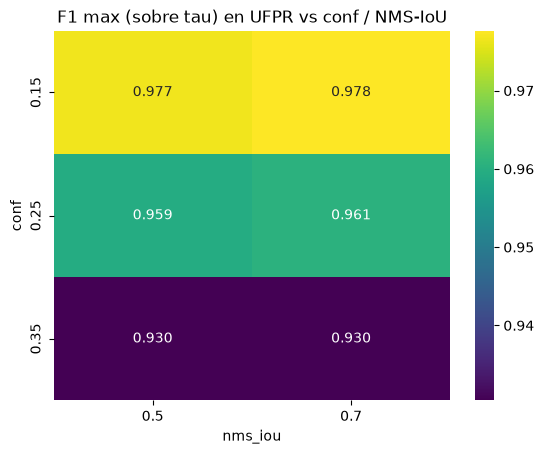

In [31]:
# Grid sencillo conf / NMS-IoU / tau; se elige el mejor F1 en UFPR (no en PUCPR externa)
rows = []
for conf in [0.15, 0.25, 0.35]:
    for iou in [0.5, 0.7]:
        for tau in [0.15, 0.25, 0.35]:
            yt_, yp_, yc_ = run_yolo_eval(yolo_coco, VEH, conf, iou, tau=tau)
            m = np.isin(yc_, ["UFPR04", "UFPR05"])
            p, r_, f, _ = precision_recall_fscore_support(yt_[m], yp_[m], average="binary", zero_division=0)
            rows.append(dict(conf=conf, nms_iou=iou, tau=tau, prec=p, rec=r_, f1=f))
sens = pd.DataFrame(rows)
print(sens.round(3).to_string(index=False))
best_hp = sens.loc[sens.f1.idxmax()]
YOLO_BEST = dict(conf=float(best_hp.conf), iou=float(best_hp.nms_iou), tau=float(best_hp.tau))
print("mejor HP (UFPR):", YOLO_BEST, "F1=", round(float(best_hp.f1), 3))

# re-eval por camara con HP elegidos
yt_b, yp_b, yc_b = run_yolo_eval(yolo_coco, VEH, YOLO_BEST["conf"], YOLO_BEST["iou"], tau=YOLO_BEST["tau"])
for c_ in ["UFPR04", "UFPR05", "PUCPR"]:
    m = yc_b == c_
    if m.sum(): print(c_, evaluate(f"YOLOv8n COCO* [{c_}]", yt_b[m], yp_b[m]))

heat = sens.groupby(["conf", "nms_iou"], as_index=False)["f1"].max()
sns.heatmap(heat.pivot(index="conf", columns="nms_iou", values="f1"), annot=True, fmt=".3f", cmap="viridis")
plt.title("F1 max (sobre tau) en UFPR vs conf / NMS-IoU"); plt.show()


In [32]:
YDIR = DATA/"yolo"
def make_yolo_dataset():
    if YDIR.exists(): shutil.rmtree(YDIR)
    for sub in ["train", "val"]:
        (YDIR/"images"/sub).mkdir(parents=True, exist_ok=True); (YDIR/"labels"/sub).mkdir(parents=True, exist_ok=True)
    for sub, n in [("train", CFG["ft_n_train"]), ("val", 40)]:
        g = man[(man.split == sub) & HAS_SP]; g = g.sample(min(n, len(g)), random_state=SEED)
        for r in g.itertuples():
            s = SP_BY_PATH[r.path]; img = imread(r.path); h, w = img.shape[:2]
            name = f"{r.cam}_{r.day}_{r.name}"
            shutil.copy(r.path, YDIR/"images"/sub/f"{name}.jpg")
            with open(YDIR/"labels"/sub/f"{name}.txt", "w") as f:
                for c, o in zip(s.corners, s.occ):
                    x1, y1 = c.min(0); x2, y2 = c.max(0)
                    f.write(f"{int(o)} {(x1+x2)/2/w:.6f} {(y1+y2)/2/h:.6f} {(x2-x1)/w:.6f} {(y2-y1)/h:.6f}\n")
    (YDIR/"data.yaml").write_text(f"path: {YDIR.as_posix()}\ntrain: images/train\nval: images/val\nnames:\n  0: libre\n  1: ocupada\n", encoding="utf-8")
yolo_ft = None
if CFG["finetune"]:
    make_yolo_dataset()
    run_name = f"pklot_ft_e{CFG['ft_epochs']}_n{CFG['ft_n_train']}_b{CFG['ft_batch']}"
    best = ROOT/"runs"/run_name/"weights"/"best.pt"
    if not best.exists():
        YOLO("yolov8n.pt").train(
            data=str(YDIR/"data.yaml"), epochs=CFG["ft_epochs"], imgsz=CFG["ft_imgsz"],
            batch=CFG["ft_batch"], device=DEVICE, lr0=0.005,
            seed=SEED, project=str(ROOT/"runs"), name=run_name, exist_ok=True,
            workers=2, verbose=False, plots=False,
        )
    yolo_ft = YOLO(str(best)); print("fine-tune weights:", best)


fine-tune weights: c:\Users\Roland\Desktop\Universidad Master IA\VA - Visión artifical\ProyectoParking\runs\pklot_ft_e20_n300_b8\weights\best.pt


In [33]:
if yolo_ft is not None:
    ys_, ps_, cs_ = [], [], []
    for r in eval_imgs.itertuples():
        s = SP_BY_PATH[r.path]; img = imread(r.path)
        res = yolo_ft.predict(img, conf=0.25, iou=0.5, imgsz=CFG["ft_imgsz"], verbose=False, device=DEVICE)[0]
        b = res.boxes; ob = b.xyxy[b.cls == 1].cpu().numpy() if len(b) else np.zeros((0, 4))
        ps_ += list(occ_from_boxes(list(s.corners), ob, img.shape, 0.4)); ys_ += list(s.occ); cs_ += [r.cam]*len(s)
    ys_, ps_, cs_ = map(np.array, (ys_, ps_, cs_))
    for c_ in ["UFPR04", "UFPR05", "PUCPR"]:
        m = cs_ == c_
        if m.sum(): print(c_, evaluate(f"YOLOv8n fine-tuned [{c_}]", ys_[m], ps_[m]))

UFPR04 {'acc': 0.9946284691136974, 'prec': 0.9901380670611439, 'rec': 0.9980119284294234, 'f1': 0.994059405940594}
UFPR05 {'acc': 0.9943573667711598, 'prec': 0.9971153846153846, 'rec': 0.9942473633748802, 'f1': 0.9956793086893903}
PUCPR {'acc': 0.595845385222193, 'prec': 0.9512195121951219, 'rec': 0.02477763659466328, 'f1': 0.04829721362229102}


## 7. Modelos fundacionales: DINOv2 y SAM (BT6b, BT6d, BT4e)
* **DINOv2-small**: embeddings de cada parche rectificado + clasificador lineal (frente a HOG: comparación clásico vs. profundo).
* **SAM (MobileSAM)**: prompt de punto en el centro de la plaza; si la máscara coincide con el polígono (IoU alta) se interpreta como un coche encajado en la plaza; el asfalto libre produce máscaras grandes que desbordan la plaza.

In [34]:
from transformers import AutoModel
from sklearn.linear_model import LogisticRegression
dino = AutoModel.from_pretrained("facebook/dinov2-small").to(DEVICE).eval()
MEAN = np.array([0.485, 0.456, 0.406], np.float32); STD = np.array([0.229, 0.224, 0.225], np.float32)
def embed(patches, bs=128, size=112):
    out = []
    with torch.no_grad():
        for i in range(0, len(patches), bs):
            b = np.stack([cv2.resize(cv2.cvtColor(p, cv2.COLOR_BGR2RGB), (size, size)) for p in patches[i:i+bs]]).astype(np.float32)/255
            b = torch.from_numpy(((b-MEAN)/STD).transpose(0, 3, 1, 2).copy()).to(DEVICE)
            h = dino(pixel_values=b).last_hidden_state
            out.append(torch.cat([h[:, 0], h[:, 1:].mean(1)], 1).cpu().numpy())
    return np.concatenate(out)

rng = np.random.default_rng(SEED)
sel = np.zeros(len(X), bool)
for m, cap in [(tr, CFG["max_patches_dino"]), (va, 1500), (te, 1500), (ext, 1500)]:
    ids = np.where(m)[0]; sel[rng.choice(ids, min(len(ids), cap), replace=False)] = True
t0 = time.time(); E = np.zeros((len(X), 768), np.float32); E[sel] = embed(X[sel]); print(f"embeddings: {time.time()-t0:.0f}s, {sel.sum()} parches")
lr = LogisticRegression(max_iter=2000, C=1.0).fit(E[tr & sel], y[tr & sel])
pred_dino = lr.predict(E)
eval_all("DINOv2+LogReg", pred_dino, mask=sel)

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

embeddings: 14s, 16497 parches


,acc,prec,rec,f1
DINOv2+LogReg [val],0.998,1.000,0.997,0.999
DINOv2+LogReg [test],0.996,0.995,0.998,0.997
DINOv2+LogReg [ext],0.992,0.984,0.999,0.991


In [35]:
from ultralytics import SAM
sam = SAM("mobile_sam.pt")
sam_imgs = pd.concat([g.head(max(1, CFG["n_sam_imgs"]//3)) for _, g in eval_imgs.groupby("cam")])
iou_list, ys_s = [], []
for r in tqdm(sam_imgs.itertuples(), total=len(sam_imgs)):
    s = SP_BY_PATH[r.path]; img = imread(r.path)
    for c, o in zip(s.corners, s.occ):
        ctr = c.mean(0); pm = poly_mask(c, img.shape)
        res = sam.predict(img, points=[[float(ctr[0]), float(ctr[1])]], labels=[1], verbose=False, device=DEVICE)[0]
        ys_s.append(o)
        # mobile_sam a veces devuelve Masks vacío (data shape [0,...]), no solo None
        if res.masks is None or getattr(res.masks, "data", None) is None or len(res.masks) == 0:
            iou_list.append(0.0); continue
        mk = cv2.resize(res.masks.data[0].cpu().numpy().astype(np.uint8), (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
        iou_list.append((mk & pm).sum()/max((mk | pm).sum(), 1))
iou_arr, ys_s = np.array(iou_list), np.array(ys_s)
taus = np.linspace(0.1, 0.9, 33); f1s = [precision_recall_fscore_support(ys_s, iou_arr > t, average="binary", zero_division=0)[2] for t in taus]
tau_best = taus[int(np.argmax(f1s))]
print("tau* =", round(float(tau_best), 2), evaluate("SAM prompt-punto (IoU mascara-plaza)", ys_s, iou_arr > tau_best), "| plazas:", len(ys_s))

  0%|          | 0/18 [00:00<?, ?it/s]

tau* = 0.23 {'acc': 0.8859126984126984, 'prec': 0.7449856733524355, 'rec': 0.9090909090909091, 'f1': 0.8188976377952756} | plazas: 1008


## 8. Comparativa, errores, overlay AR y demo interactiva (BT1b, BT1c, BT2f)

,acc,prec,rec,f1
Otsu+morfologia [val],0.977,0.990,0.978,0.984
Otsu+morfologia [test],0.960,0.964,0.965,0.965
Otsu+morfologia [ext],0.949,0.944,0.943,0.943
HOG+SVM [val],0.953,0.966,0.968,0.967
HOG+SVM [test],0.943,0.955,0.945,0.950
HOG+SVM [ext],0.926,0.902,0.937,0.919
YOLOv8n COCO [UFPR04],0.972,0.980,0.958,0.969
YOLOv8n COCO [UFPR05],0.939,0.976,0.930,0.952
YOLOv8n COCO [PUCPR],0.798,0.961,0.533,0.686
YOLOv8n COCO* [UFPR04],0.987,0.994,0.978,0.986


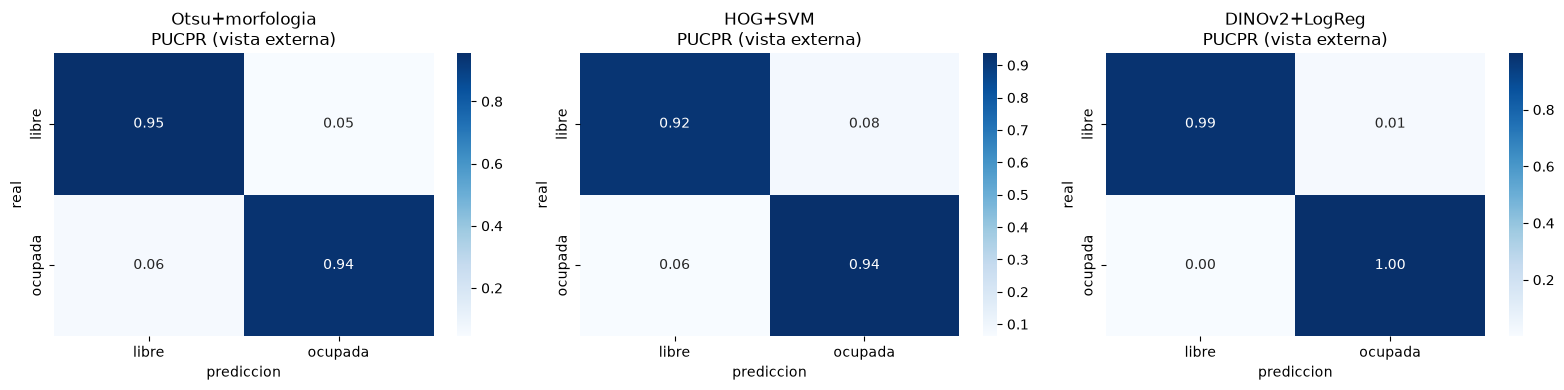

                 otsu    hog
cam    weather              
PUCPR  Cloudy   0.966  0.931
       Rainy    0.931  0.936
       Sunny    0.946  0.919
UFPR04 Cloudy   0.974  0.928
       Rainy    0.910  0.940
       Sunny    0.937  0.927
UFPR05 Cloudy   0.996  0.969
       Rainy    0.981  0.955
       Sunny    0.953  0.951


In [36]:
tab = pd.DataFrame(RESULTS).T.round(3); display(tab); tab.to_csv(OUT/"resultados.csv")
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
for ax, (nm, pr, mk) in zip(axs, [("Otsu+morfologia", pred_cls, ext), ("HOG+SVM", pred_hog, ext), ("DINOv2+LogReg", pred_dino, ext & sel)]):
    sns.heatmap(confusion_matrix(y[mk], pr[mk], normalize="true"), annot=True, fmt=".2f", cmap="Blues", ax=ax, xticklabels=["libre", "ocupada"], yticklabels=["libre", "ocupada"])
    ax.set_title(f"{nm}\nPUCPR (vista externa)"); ax.set_xlabel("prediccion"); ax.set_ylabel("real")
plt.tight_layout(); plt.show()
d = sp.assign(otsu=pred_cls == y, hog=pred_hog == y)
print(d[te | ext].groupby(["cam", "weather"])[["otsu", "hog"]].mean().round(3))

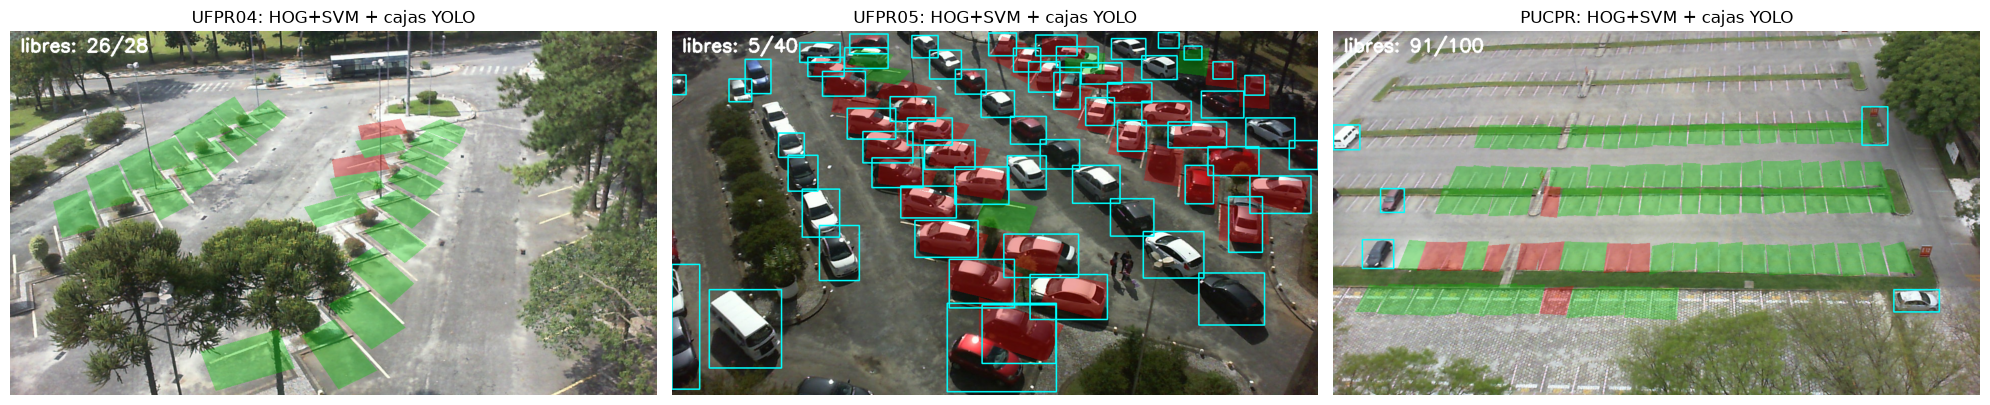

In [37]:
def overlay(path, pred_per_space, boxes=None, alpha=.35):
    img = imread(path); ov = img.copy(); s = SP_BY_PATH[path]
    for c, p in zip(s.corners, pred_per_space):
        cv2.fillPoly(ov, [c.astype(np.int32)], (0, 0, 220) if p else (0, 200, 0))
    out = cv2.addWeighted(ov, alpha, img, 1-alpha, 0)
    for b in (boxes if boxes is not None else []): cv2.rectangle(out, tuple(map(int, b[:2])), tuple(map(int, b[2:])), (255, 255, 0), 2)
    free = int(len(pred_per_space)-np.sum(pred_per_space)); cv2.putText(out, f"libres: {free}/{len(pred_per_space)}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255,255,255), 3)
    return cv2.cvtColor(out, cv2.COLOR_BGR2RGB)
fig, axs = plt.subplots(1, 3, figsize=(20, 4.6))
for ax, c_ in zip(axs, ["UFPR04", "UFPR05", "PUCPR"]):
    p = eval_imgs[eval_imgs.cam == c_].path.iloc[0]; idx = np.where(sp.path.values == p)[0]
    boxes = yolo_coco.predict(imread(p), conf=.25, iou=.7, imgsz=1280, classes=VEH, verbose=False, device=DEVICE)[0].boxes.xyxy.cpu().numpy()
    ax.imshow(overlay(p, pred_hog[idx], boxes)); ax.set_title(f"{c_}: HOG+SVM + cajas YOLO"); ax.axis("off")
plt.tight_layout(); plt.show()

In [38]:
import ipywidgets as W
from IPython.display import display
paths = list(eval_imgs.path)
def demo(i=0, conf=.25, iou=.7, tau=.25):
    p = paths[i]; img = imread(p); s = SP_BY_PATH[p]
    b = yolo_coco.predict(img, conf=conf, iou=iou, imgsz=1280, classes=VEH, verbose=False, device=DEVICE)[0].boxes.xyxy.cpu().numpy()
    pr = occ_from_boxes(list(s.corners), b, img.shape, tau); acc = (pr == s.occ.values).mean()
    plt.figure(figsize=(14, 5)); plt.imshow(overlay(p, pr, b)); plt.axis("off"); plt.title(f"{s.cam.iloc[0]} | acierto por plaza = {acc:.3f} | cajas = {len(b)}"); plt.show()
W.interact(demo, i=W.IntSlider(0, 0, len(paths)-1), conf=W.FloatSlider(.25, min=.05, max=.8, step=.05), iou=W.FloatSlider(.7, min=.2, max=.95, step=.05), tau=W.FloatSlider(.25, min=.05, max=.8, step=.05));

interactive(children=(IntSlider(value=0, description='i', max=119), FloatSlider(value=0.25, description='conf'…

## 9. Conclusiones y limitaciones (completar con los resultados obtenidos)
* Mejor método por cámara y entre vistas (UFPR → PUCPR): ver tabla de resultados.
* Fallos típicos: sombras, lluvia, coches parcialmente fuera del polígono, plazas tapadas por árboles.
* Limitaciones: PKLot no incluye cajas de coche; la evaluación de coches se hace a través de la ocupación de plaza.
* Reproducibilidad: `SEED=42`, manifiesto en `outputs/manifest.csv`, resultados en `outputs/resultados.csv`.